In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.makedirs('sparse_data', exist_ok=True)

In [2]:
def generate_sparse_batch(batch_size, n, p, dataset_name):
    """
    Returns x: [batch_size, n] where each entry is zero w.p. (1-p),
    otherwise uniform in [-1, 1].
    Also saves the generated batch to a file named {dataset_name}.pt
    """
    x = torch.zeros(batch_size, n)
    mask = (torch.rand(batch_size, n) < p)  # boolean mask for non-zero
    x[mask] = 2 * torch.rand(mask.sum()) - 1  # fill those with uniform in [-1,1]
    
    # Save the generated batch
    torch.save(x, f'sparse_data/{dataset_name}.pt')
    
    return x

In [3]:
class TwoLayerNet(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.W_in = nn.Linear(n_in, n_hidden, bias=False)
        self.relu = nn.ReLU()
        self.W_out = nn.Linear(n_hidden, n_out, bias=False)

    def forward(self, x, testing=False):
        hidden = self.relu(self.W_in(x))
        out = self.W_out(hidden)
        if testing:
            return out, hidden
        
        return out


In [4]:

n = 100   # Input dimension
m = 50    # Hidden dimension (m < n)
p = 0.05   # Probability that x_i is non-zero
batch_size = 256
lr = 1e-3
num_epochs = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
model = TwoLayerNet(n, m, n)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
model.to(device)

TwoLayerNet(
  (W_in): Linear(in_features=100, out_features=50, bias=False)
  (relu): ReLU()
  (W_out): Linear(in_features=50, out_features=100, bias=False)
)

In [6]:

for epoch in range(num_epochs):
    x_batch = generate_sparse_batch(batch_size, n, p, f"train_{epoch}")
    x_batch = x_batch.to(device)
    # Target = ReLU(x) elementwise
    y_true = torch.relu(x_batch)
    # print(f"x_batch on device: {x_batch.device}")
    # print(f"y_true on device: {y_true.device}")
    
    y_pred = model(x_batch)
    loss = criterion(y_pred, y_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss = {loss.item():.6f}")



Epoch 10/1000, Loss = 0.009475
Epoch 20/1000, Loss = 0.008296
Epoch 30/1000, Loss = 0.008247
Epoch 40/1000, Loss = 0.007296
Epoch 50/1000, Loss = 0.007674
Epoch 60/1000, Loss = 0.007538
Epoch 70/1000, Loss = 0.007777
Epoch 80/1000, Loss = 0.007335
Epoch 90/1000, Loss = 0.006713
Epoch 100/1000, Loss = 0.006801
Epoch 110/1000, Loss = 0.006929
Epoch 120/1000, Loss = 0.006328
Epoch 130/1000, Loss = 0.006439
Epoch 140/1000, Loss = 0.006802
Epoch 150/1000, Loss = 0.006174
Epoch 160/1000, Loss = 0.006222
Epoch 170/1000, Loss = 0.006339
Epoch 180/1000, Loss = 0.006235
Epoch 190/1000, Loss = 0.005434
Epoch 200/1000, Loss = 0.005250
Epoch 210/1000, Loss = 0.005600
Epoch 220/1000, Loss = 0.005423
Epoch 230/1000, Loss = 0.006252
Epoch 240/1000, Loss = 0.005394
Epoch 250/1000, Loss = 0.005530
Epoch 260/1000, Loss = 0.005474
Epoch 270/1000, Loss = 0.005597
Epoch 280/1000, Loss = 0.005282
Epoch 290/1000, Loss = 0.005120
Epoch 300/1000, Loss = 0.005376
Epoch 310/1000, Loss = 0.005608
Epoch 320/1000, L

In [7]:

# Compare final MSE with naive approaches
naive_loss = criterion(torch.zeros_like(x_batch), y_true).item()
print(f"Naive zero-output MSE: {naive_loss:.6f}")

# Model's final MSE on a fresh batch
test_x = generate_sparse_batch(batch_size, n, p, f"test")
test_x = test_x.to(device)
test_y_true = torch.relu(test_x)
test_y_pred = model(test_x)
test_loss = criterion(test_y_pred, test_y_true).item()
print(f"Model test MSE: {test_loss:.6f}")


Naive zero-output MSE: 0.007891
Model test MSE: 0.004720


In [8]:
print(f"Expectation MSE if model ops 0 always {p/6:.6f}")
print(f"Expectation MSE if model copies m < n inputs to hidden layer: {((n-m)/n)*(p/6):.6f}")

Expectation MSE if model ops 0 always 0.008333
Expectation MSE if model copies m < n inputs to hidden layer: 0.004167


Test loss on this set is still higher than the expected MSE loss

In [9]:
data = torch.load(f'sparse_data/test.pt')
# Load test data and move to device
data = data.to(device)

# Get model predictions
with torch.no_grad():  # No need to track gradients for inference
    predictions = model(data)

# Print some statistics about the predictions
print(f"Predictions shape: {predictions.shape}")
print(f"Number of non-zero predictions: {(predictions != 0).sum().item()}")
print(f"Mean prediction value: {predictions.mean().item():.6f}")
print(f"Max prediction value: {predictions.max().item():.6f}")


# num_examples = 3
# print("\nFirst few examples:")
# for i in range(num_examples):
#     print(f"\nExample {i+1}:")
#     print(f"Input (non-zero elements): {data[i].nonzero().shape[0]}")
#     print(f"Prediction (non-zero elements): {predictions[i].nonzero().shape[0]}")
#     print("====Stats of input=====")
#     print(f"Mean input value: {data[i].mean().item():.6f}")
#     print(f"Max input value: {data[i].max().item():.6f}")
#     print(f"Min input value: {data[i].min().item():.6f}")
#     print("====Stats of output=====")
#     print(f"Mean prediction value: {predictions[i].mean().item():.6f}")
#     print(f"Max prediction value: {predictions[i].max().item():.6f}")
#     print(f"Min prediction value: {predictions[i].min().item():.6f}")


Predictions shape: torch.Size([256, 100])
Number of non-zero predictions: 25500
Mean prediction value: 0.012125
Max prediction value: 0.683611


C:\Users\techi\AppData\Local\Temp\ipykernel_30396\1017542846.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'sparse_data/test.pt')


In [10]:
test_input = torch.zeros(n, dtype=torch.float32)

# Ensure at least 1-5% non-zero elements
mask = torch.rand(n) < p
num_nonzero = mask.sum().item()

if num_nonzero == 0:
    # If no elements selected, randomly choose 1-5% of indices
    min_nonzero = max(1, int(0.01 * n))  # At least 1 element
    max_nonzero = max(2, int(0.05 * n))  # At least 2 elements for range
    num_nonzero = torch.randint(min_nonzero, max_nonzero + 1, (1,)).item()
    indices = torch.randperm(n)[:num_nonzero]
    mask = torch.zeros(n, dtype=bool)
    mask[indices] = True

test_input[mask] = 2 * torch.rand(num_nonzero) - 1  # Values between -1 and 1

test_input = test_input.to(device)
print(f"test_input: {test_input}")
print(f"Number of non-zero elements: {num_nonzero}")
print("\nNon-zero elements and their indices:")
nonzero_idx = test_input.nonzero().squeeze()
if num_nonzero == 1:
    nonzero_idx = nonzero_idx.unsqueeze(0)  # Make it a 1D array
nonzero_vals = test_input[nonzero_idx]
if num_nonzero == 1:
    nonzero_vals = nonzero_vals.unsqueeze(0)  # Make it a 1D array

with torch.no_grad():
    test_output, hidden = model(test_input, testing=True)


for idx, val in zip(nonzero_idx, nonzero_vals):
    print(f"Index {idx.item()}: {val.item():.4f}, prediction: {test_output[idx.item()].item():.4f}")
    
print("\nModel output statistics:")
print(f"Number of non-zero predictions: {(test_output != 0).sum().item()}")
print(f"Max prediction value: {test_output.max().item():.4f}")
print(f"Mean prediction value: {test_output.mean().item():.4f}")

test_input: tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.6430,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.3099,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.4132,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.2240,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0

In [14]:
test_input

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.6430,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.3099,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.4132,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.2240,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

In [15]:
hidden

tensor([0.0000, 0.0000, 0.0007, 0.0098, 0.0010, 0.0000, 0.0000, 0.0000, 0.0138,
        0.0047, 0.0727, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0020, 0.0000, 0.0000, 0.0000, 0.0458, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0061, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0686, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0061, 0.0000], device='cuda:0')

In [16]:
test_output

tensor([-2.6815e-03, -2.5131e-02, -8.0862e-04, -5.2002e-04, -4.0504e-04,
         1.3374e-02,  2.2571e-02, -9.7138e-03, -3.8405e-03, -5.0639e-03,
         1.6416e-03, -5.8418e-03,  2.8237e-03, -1.4562e-02, -5.6237e-03,
        -3.6255e-03, -8.8914e-03, -3.3110e-03,  4.2614e-03,  2.2321e-02,
        -7.5710e-03,  1.4995e-02, -1.0670e-02,  1.9617e-04, -3.9271e-03,
        -2.8940e-03, -1.2728e-02,  4.4444e-03, -1.4027e-03,  7.8503e-03,
        -8.1524e-03, -3.2865e-03,  1.2588e-02,  2.3194e-03,  4.0959e-03,
         1.2570e-03, -1.7456e-02,  4.7608e-05,  1.0151e-03,  6.9631e-03,
        -1.3417e-02,  4.8433e-03, -1.1345e-03,  1.2818e-04,  1.4742e-03,
        -4.4252e-03, -2.0441e-03, -2.6005e-03, -3.5569e-04,  5.9811e-03,
        -5.3230e-04,  1.3805e-02, -1.7225e-02,  6.3811e-03, -4.8028e-03,
        -4.4859e-03,  6.2602e-03, -7.8259e-03, -3.3155e-03, -4.8028e-03,
         4.5644e-03,  4.4626e-03, -2.3094e-03, -1.3581e-02, -4.6200e-03,
         2.1898e-02,  1.6709e-03,  6.3460e-02, -8.1

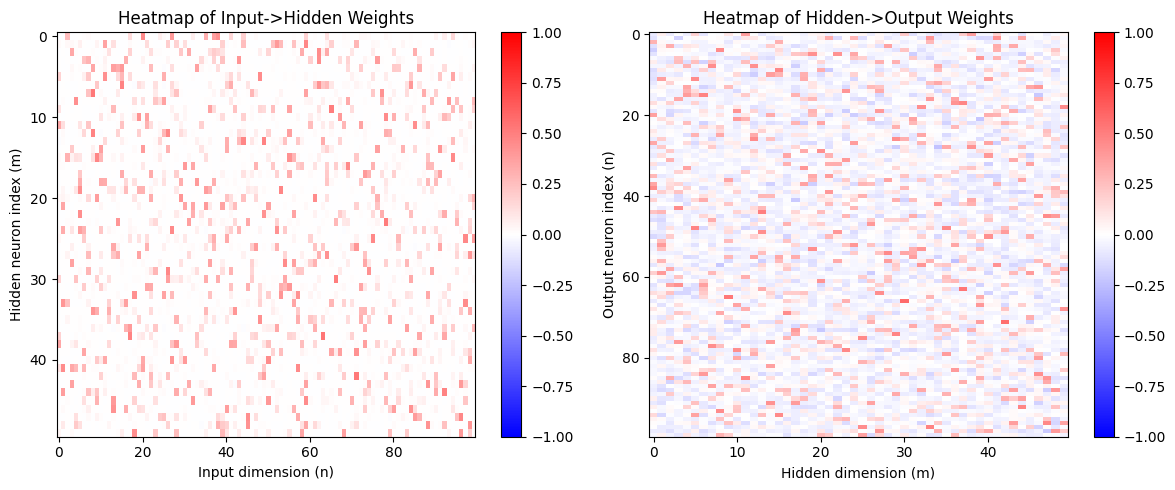

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot input->hidden weights
plt.subplot(1, 2, 1)
W_in = model.W_in.weight.detach().cpu().numpy()
plt.imshow(W_in, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Heatmap of Input->Hidden Weights")
plt.xlabel("Input dimension (n)")
plt.ylabel("Hidden neuron index (m)")

# Plot hidden->output weights 
plt.subplot(1, 2, 2)
W_out = model.W_out.weight.detach().cpu().numpy()
plt.imshow(W_out, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Heatmap of Hidden->Output Weights")
plt.xlabel("Hidden dimension (m)")
plt.ylabel("Output neuron index (n)")

plt.tight_layout()
plt.show()


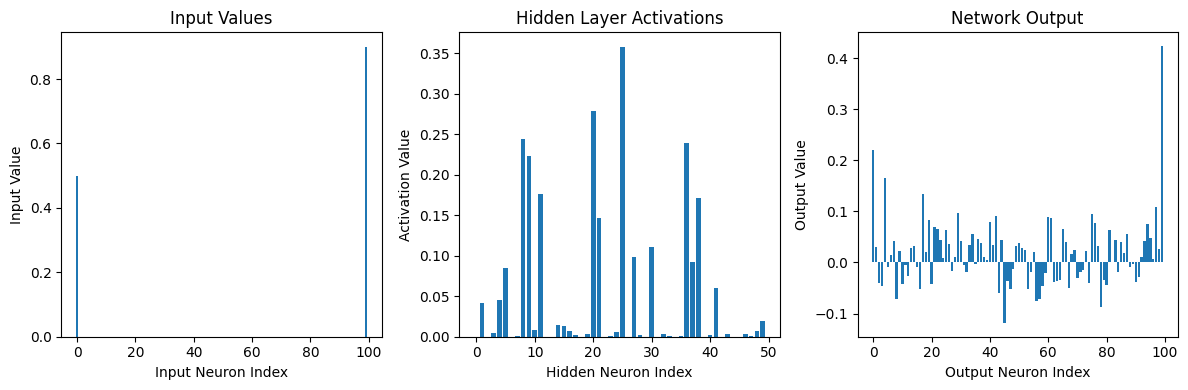

In [44]:
# Let's create a custom input with multiple positives
test_input = torch.zeros(n)
test_input = test_input.to(device)
test_input[0] = 0.5
# test_input[10] = 0.8
test_input[99] = 0.9
test_input = test_input.unsqueeze(0)  # batch dimension

with torch.no_grad():
    hidden_acts = model.relu(model.W_in(test_input))
    output = model.W_out(hidden_acts)

# Plot input, hidden activations and output
plt.figure(figsize=(12, 4))

# Plot input
plt.subplot(1, 3, 1)
plt.bar(range(test_input.shape[1]), test_input.squeeze().cpu())
plt.title("Input Values")
plt.xlabel("Input Neuron Index") 
plt.ylabel("Input Value")

# Plot hidden activations
plt.subplot(1, 3, 2)
plt.bar(range(hidden_acts.shape[1]), hidden_acts.squeeze().cpu())
plt.title("Hidden Layer Activations")
plt.xlabel("Hidden Neuron Index")
plt.ylabel("Activation Value")

# Plot output
plt.subplot(1, 3, 3)
plt.bar(range(output.shape[1]), output.squeeze().cpu())
plt.title("Network Output")
plt.xlabel("Output Neuron Index")
plt.ylabel("Output Value")

plt.tight_layout()
plt.show()


In [40]:
# Find indices where hidden activations are greater than 0.05
indices = (hidden_acts.squeeze() > 0.05).nonzero().squeeze()
values = hidden_acts.squeeze()[indices]
print("Indices and values of hidden activations greater than 0.05:")
print(torch.stack([indices.float(), values], dim=1))

Indices and values of hidden activations greater than 0.05:
tensor([[ 5.0000,  0.0848],
        [ 8.0000,  0.2438],
        [ 9.0000,  0.2227],
        [11.0000,  0.1762],
        [20.0000,  0.2790],
        [21.0000,  0.1471],
        [25.0000,  0.3580],
        [27.0000,  0.0985],
        [30.0000,  0.1107],
        [36.0000,  0.2392],
        [37.0000,  0.0919],
        [38.0000,  0.1719],
        [41.0000,  0.0601]], device='cuda:0')


In [46]:
import numpy as np

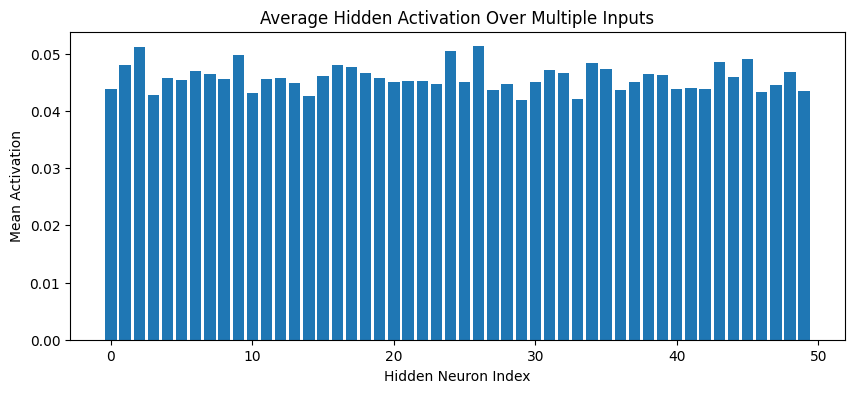

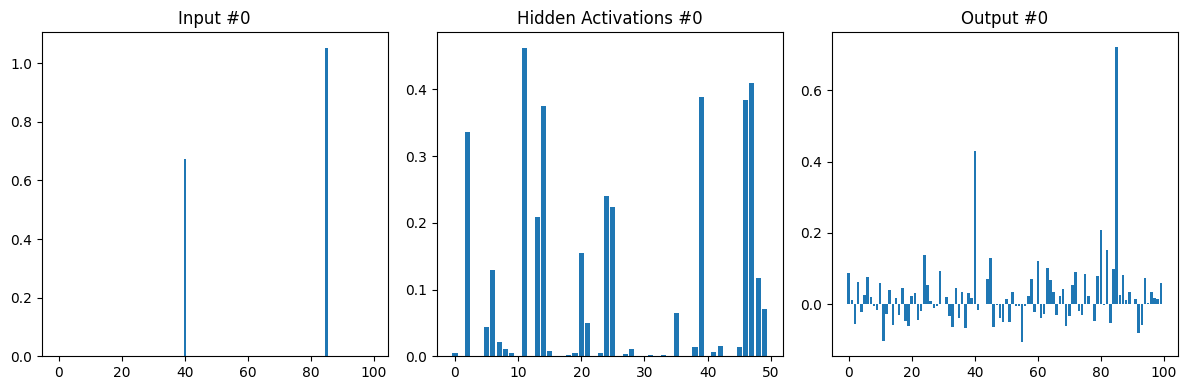

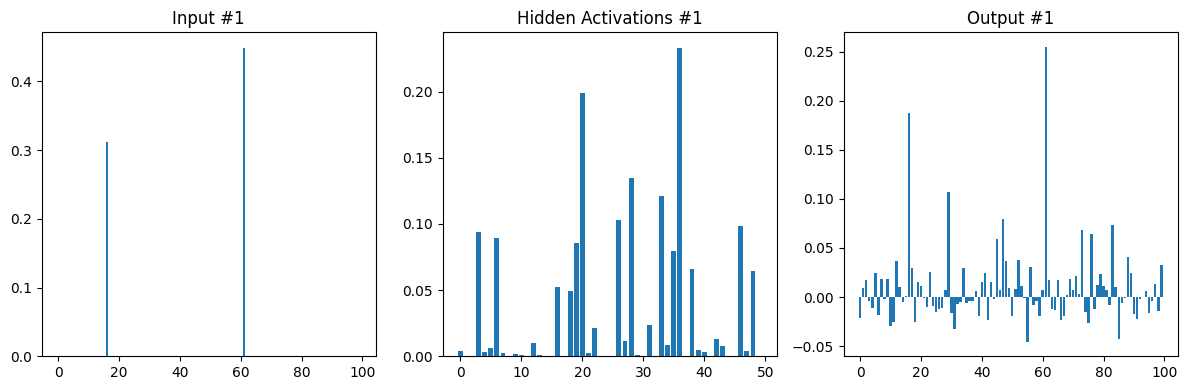

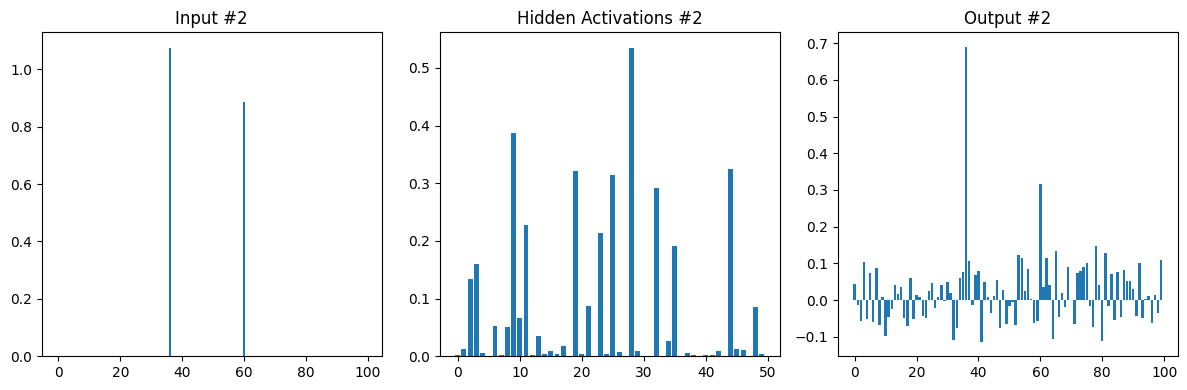

Active frequency per neuron: [0.703  0.6845 0.6541 0.672  0.6943 0.6854 0.6422 0.6591 0.6344 0.6775
 0.7012 0.6338 0.666  0.6863 0.682  0.7083 0.6537 0.7085 0.6292 0.679
 0.6845 0.6674 0.6775 0.6582 0.6827 0.6433 0.6781 0.6441 0.7066 0.6595
 0.6843 0.7328 0.6966 0.6383 0.7156 0.6819 0.6523 0.6351 0.7068 0.702
 0.747  0.7318 0.6728 0.7013 0.6794 0.6912 0.7661 0.705  0.692  0.6373]
Average activation per neuron: [0.04377872 0.04802339 0.05118904 0.04283886 0.04569758 0.04547783
 0.04692283 0.04648682 0.04557313 0.04978278 0.04318066 0.0456099
 0.045681   0.04491702 0.04253694 0.04601387 0.04807521 0.04772231
 0.04665504 0.04582237 0.04506848 0.04529152 0.0451337  0.04470645
 0.05046532 0.04499362 0.05126515 0.04360863 0.04477115 0.04198236
 0.04503752 0.04721324 0.04660458 0.042107   0.04841551 0.04730629
 0.04369827 0.04503686 0.04640555 0.04625327 0.04378606 0.04400925
 0.04378702 0.04855206 0.04591073 0.04899092 0.0433288  0.04448029
 0.04679845 0.04350993]


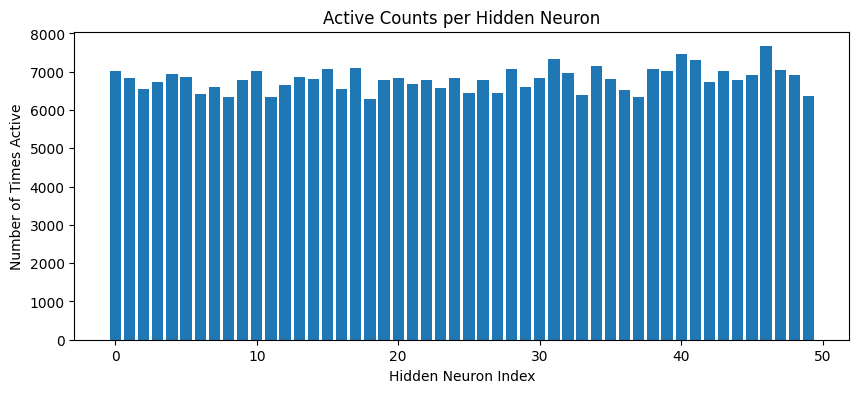

In [59]:
n_test = 10000
activations_list = []
outputs_list = []
inputs_list = []

for i in range(n_test):
    test_input = torch.zeros(n, device=device)
    pos_indices = torch.randperm(n)[:2]
    test_input[pos_indices[0]] = torch.rand(1).item() + 0.1
    test_input[pos_indices[1]] = torch.rand(1).item() + 0.1
    test_input = test_input.unsqueeze(0)

    with torch.no_grad():
        hidden = model.relu(model.W_in(test_input))
        output = model.W_out(hidden)

    inputs_list.append(test_input.squeeze().cpu().numpy())
    activations_list.append(hidden.squeeze().cpu().numpy())
    outputs_list.append(output.squeeze().cpu().numpy())

activations_array = np.stack(activations_list, axis=0)
outputs_array = np.stack(outputs_list, axis=0)
inputs_array = np.stack(inputs_list, axis=0)

threshold = 1e-3
active_counts = (activations_array > threshold).sum(axis=0)
active_frequency = active_counts / n_test
avg_activation = activations_array.mean(axis=0)

plt.figure(figsize=(10,4))
plt.bar(range(len(avg_activation)), avg_activation)
plt.title("Average Hidden Activation Over Multiple Inputs")
plt.xlabel("Hidden Neuron Index")
plt.ylabel("Mean Activation")
plt.show()


for i in range(n_test):
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    axs[0].bar(range(n), inputs_array[i])
    axs[0].set_title(f"Input #{i}")
    axs[1].bar(range(m), activations_array[i])
    axs[1].set_title(f"Hidden Activations #{i}")
    axs[2].bar(range(n), outputs_array[i])
    axs[2].set_title(f"Output #{i}")
    plt.tight_layout()
    plt.show()
    if i == 2:
        break

print("Active frequency per neuron:", active_frequency)
print("Average activation per neuron:", avg_activation)
plt.figure(figsize=(10,4))
plt.bar(range(len(active_counts)), active_counts)
plt.title("Active Counts per Hidden Neuron")
plt.xlabel("Hidden Neuron Index") 
plt.ylabel("Number of Times Active")
plt.show()


In [52]:
from sklearn.decomposition import PCA


In [54]:
W_in.shape

(50, 100)

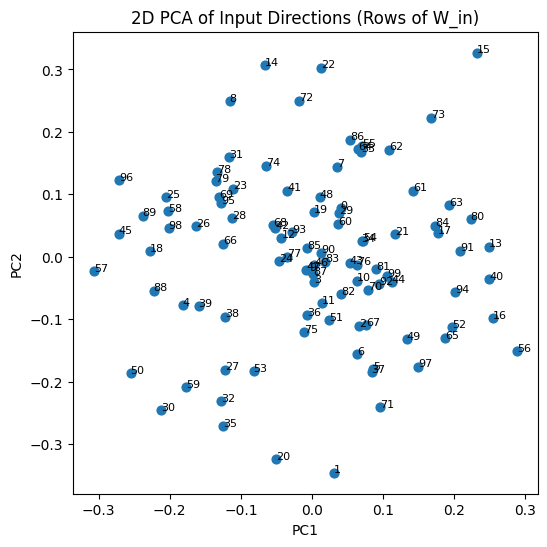

In [53]:
W_in = model.W_in.weight.detach().cpu().numpy()
directions = W_in.T

pca = PCA(n_components=2)
pca_directions = pca.fit_transform(directions)

plt.figure(figsize=(6,6))
plt.scatter(pca_directions[:, 0], pca_directions[:, 1], s=40)
for i in range(n):
    plt.text(pca_directions[i, 0], pca_directions[i, 1], str(i), fontsize=8)
plt.title("2D PCA of Input Directions (Rows of W_in)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
